In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 
import open3d as o3d
import os 
import sys

# Only needed for tutorial
sys.path.append('..')

import open3d.examples as o3dtut
# Change to True if you want to interact with the visualization windows
o3dtut.interactive = not 'CI' in os.environ

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [15]:
color_raw = o3d.io.read_image('Depth/chair.png')
depth_raw = o3d.io.read_image('Depth/chair1.png')
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(color_raw,
                                                               depth_raw)

print(rgbd_image)

RGBDImage of size 
Color image : 1920x1080, with 1 channels.
Depth image : 1920x1080, with 1 channels.
Use numpy.asarray to access buffer data.


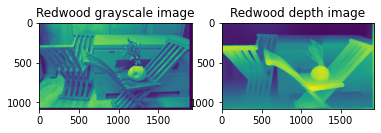

In [16]:
plt.subplot(1, 2, 1)
plt.title('Redwood grayscale image')
plt.imshow(rgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('Redwood depth image')
plt.imshow(rgbd_image.depth)
plt.show()

In [28]:
camera_intrinsic = o3d.camera.PinholeCameraIntrinsic(width=w, height=h, fx=1758.23, fy=1758.23, cx=947.17, cy=552.44)

In [29]:
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_image, camera_intrinsic)

pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
o3d.visualization.draw_geometries([pcd])

In [19]:
w = 1920
h = 1080

Q = [1 0 0 -cx, 0 1 0 -cy, 0 0 0 f, 0 0 -1/Tx 0]

In [22]:
print(camera_intrinsic.intrinsic_matrix)

[[1.75823e+03 0.00000e+00 9.47170e+02]
 [0.00000e+00 1.75823e+03 5.52440e+02]
 [0.00000e+00 0.00000e+00 1.00000e+00]]
